# Retail Sales Performance Analysis

## Overview

This project analyses retail sales data to identify trends in sales, profitability, product performance and regional performance.

The analysis demonstrates an end-to-end data analytics workflow using Python and Pandas, from data loading and quality assessment through explotary analysis, visualisation and business recommendations.

### Tools
- Python
- Pandas
- Matplotlib
- Jupyter Notebook

## 1. Business Objective

The objective of this analysis is to evaluate retail sales performance and identify key trends and area requiring further attention.

The analysis aims to answer the following questions.

1. How have sales changed over time?
2. Which product categories generate the highest profit?
3. Which categories generate the highest profit?
4. Which regions perform best?
5. Which sub-categories contribute most to sales and profit?
6. Are there areas where strong sales do not translate into strong profitability?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel("sample_superstore.xls")


In [ ]:
df.head()
#first 5 rows

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [ ]:
df.shape
#(rows,columns)

(10194, 21)

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10194 non-null  object        
 7   Segment         10194 non-null  object        
 8   Country/Region  10194 non-null  object        
 9   City            10194 non-null  object        
 10  State/Province  10194 non-null  object        
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  object        
 13  Product ID      10194 non-null  object        
 14  Category        10194 non-null  object        
 15  Su

In [ ]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-04-29 11:48:25.002942720,2025-05-03 10:52:45.626839296,228.225854,3.791838,0.155385,28.673417
min,1.000000,2023-01-03 00:00:00,2023-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,2024-05-14 00:00:00,2024-05-19 00:00:00,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,2025-06-25 00:00:00,2025-06-28 00:00:00,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,2026-05-14 00:00:00,2026-05-18 00:00:00,209.500000,5.000000,0.200000,29.297925
max,10194.000000,2026-12-30 00:00:00,2027-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2942.898656,NaN,NaN,619.906839,2.228317,0.206249,232.465115


## We are answering "What data do I actually have?"

## 3. Dataset Overview  ^^^^

The dataset contains retail transaction records including order dates,
customer information, geographic information, product categories,
sales, quantity, discounts and profit.

Before performing analysis, the dataset was inspected to understand
its structure, data types and potential data-quality issues.

In [ ]:
df.isnull().sum()
#tell us which columns have missing values

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country/Region,0
City,0


In [ ]:
df.duplicated().sum()
#check for duplicated rows
#True = duplicated
#False = unique
#sum(), True = 1 , False = 0. it will count

np.int64(0)

In [ ]:
df.dtypes
#data type of each column

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country/Region,object
City,object


In [ ]:
df["Category"].unique()
#unique values of a column

array(['Office Supplies', 'Furniture', 'Technology'], dtype=object)

In [ ]:
df["Region"].unique()

array(['Central', 'East', 'South', 'West'], dtype=object)

In [ ]:
df["Segment"].unique()

array(['Consumer', 'Home Office', 'Corporate'], dtype=object)

In [ ]:
df["Order Date"].min()
#checking dates is important

Timestamp('2023-01-03 00:00:00')

In [ ]:
df["Order Date"].max()

Timestamp('2026-12-30 00:00:00')

In [ ]:
df["Order Date"].dtype
#have to make sure python recognises the column as date

dtype('<M8[ns]')

###Notes: Dont clean unnecessarily



> Identify > Understand > Decide > Document > Clean

not all blanks/duplicates are wrong



In [ ]:
#Example the dates need conversion

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [ ]:
#Create useful time variables
#year
df["Order Year"] = df["Order Date"].dt.year

In [ ]:
#month
df["Order Month"] = df["Order Date"].dt.month

In [ ]:
#month name
df["Order Month Name"] = df["Order Date"].dt.month_name()

In [ ]:
#Year - month
df["Year Month"] = df["Order Date"].dt.to_period("M").astype(str)

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Year Month
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,1,January,2023-01
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,1,January,2023-01
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Labels,Avery 508,11.784,3,0.2,4.2717,2023,1,January,2023-01
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,2023,1,January,2023-01
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,2023,1,January,2023-01


###**Save the cleaned dataset**

In [ ]:
df.to_csv("superstore_cleaned.csv", index=False)
#index = false, to exclude the DataFrame's index as the first column

###**Now We Go Into EDA**

>Explotary Data Analysis



####Analysis 1 - Overal Sales

In [ ]:
total_sales = df["Sales"].sum()
print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,326,534.35


In [ ]:
total_profit = df["Profit"].sum()
print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $292,296.81


In [ ]:
total_quantity = df["Quantity"].sum()
print(f"Total Quantity Sold: {total_quantity:,}")

Total Quantity Sold: 38,654


####Analysis 2 - Sales by Category

In [ ]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

,Sales
Category,
Technology,839893.2790
Furniture,754747.7613
Office Supplies,731893.3140


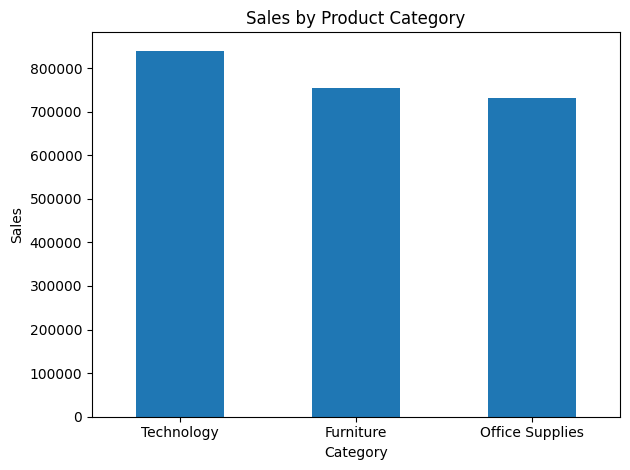

In [ ]:
category_sales.plot(kind="bar")

plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

####Analysis 3 - Profit by Category

In [ ]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

category_profit

,Profit
Category,
Technology,146543.3756
Office Supplies,126023.4434
Furniture,19729.9956


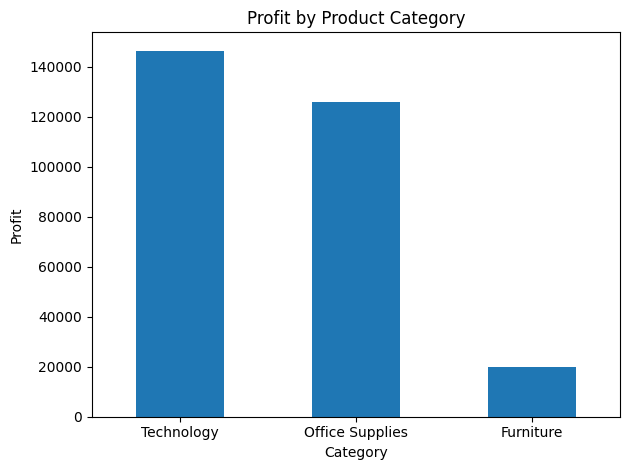

In [ ]:
category_profit.plot(kind="bar")

plt.title("Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

####Analysis 4 - Regional Performance
>Sales & Profit by Region

In [ ]:
region_performance = (
    df.groupby("Region")[["Sales", "Profit"]] #use list [] to call 2 category
    .sum()
    .sort_values("Sales", ascending=False)
)

region_performance

,Sales,Profit
Region,,
West,739813.6085,110798.8170
East,691828.1680,94883.2603
Central,503170.6728,39865.3070
South,391721.9050,46749.4303


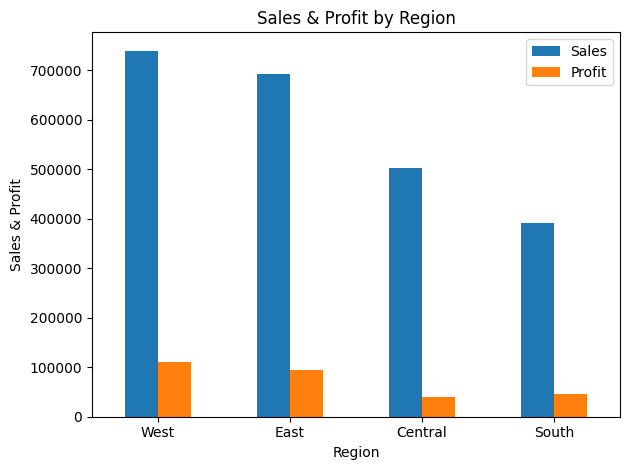

In [ ]:
region_performance.plot(kind="bar")

plt.title("Sales & Profit by Region")
plt.xlabel("Region")
plt.ylabel("Sales & Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

####Analysis 5 - Monthly Sales Trend
Important charts

In [ ]:
monthly_sales = (
    df.groupby("Year Month")["Sales"]
    .sum()
)

monthly_sales

,Sales
Year Month,
2023-01,14518.0550
2023-02,4519.8920
2023-03,56933.9090
2023-04,28295.3450
2023-05,26319.7670
2023-06,34669.4796
2023-07,33946.3930
2023-08,28918.3385
2023-09,82670.4288


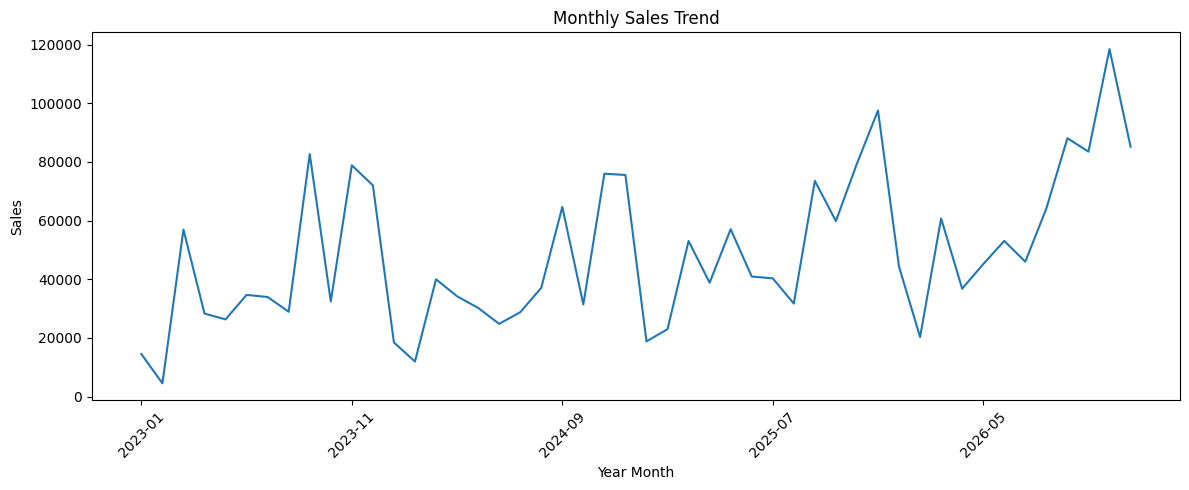

In [ ]:
plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Year Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Can look for:

- growth
- declines
- spikes
- seasonality
- unusual periods

####Analysis 6 - Sub Category


In [ ]:
subcategory_performance = (
    df.groupby("Sub-Category")[["Sales","Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

subcategory_performance

,Sales,Profit
Sub-Category,,
Chairs,335768.2490,27223.5323
Phones,331842.6400,45050.8265
Storage,224644.5540,21285.1115
Tables,208020.1820,-17753.2061
Binders,207354.8810,31426.1003
Machines,189925.0310,3461.9769
Accessories,167380.3180,41936.6357
Copiers,150745.2900,56093.9365
Bookcases,115361.2043,-3632.0736


####Look for top 10 by sales of the sub category

In [ ]:
subcategory_performance.head(10)

,Sales,Profit
Sub-Category,,
Chairs,335768.2490,27223.5323
Phones,331842.6400,45050.8265
Storage,224644.5540,21285.1115
Tables,208020.1820,-17753.2061
Binders,207354.8810,31426.1003
Machines,189925.0310,3461.9769
Accessories,167380.3180,41936.6357
Copiers,150745.2900,56093.9365
Bookcases,115361.2043,-3632.0736


###Analysis 7 - The Sales vs Profit

In [ ]:
product_performance = (
    df.groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
)

product_performance

,Sales,Profit
Sub-Category,,
Accessories,167380.3180,41936.6357
Appliances,108213.1850,18329.4844
Art,27659.0140,6653.1962
Binders,207354.8810,31426.1003
Bookcases,115361.2043,-3632.0736
Chairs,335768.2490,27223.5323
Copiers,150745.2900,56093.9365
Envelopes,16528.3620,6988.0247
Fasteners,8532.2400,2428.6358


In [ ]:
#calculate profit margin
#create new column inside the product_performance table/analysis
#using like indexes
product_performance["Profit Margin"] = (
    product_performance["Profit"]
    / product_performance["Sales"]
    * 100
)

In [ ]:
#then you call and sort it highest to low
#to see which are the one that actually profitable

product_performance.sort_values("Profit Margin", ascending=False)

,Sales,Profit,Profit Margin
Sub-Category,,,
Labels,12695.0420,5572.7780,43.897279
Paper,79540.5380,34511.5070,43.388576
Envelopes,16528.3620,6988.0247,42.278991
Copiers,150745.2900,56093.9365,37.211071
Fasteners,8532.2400,2428.6358,28.464223
Accessories,167380.3180,41936.6357,25.054700
Art,27659.0140,6653.1962,24.054351
Appliances,108213.1850,18329.4844,16.938310
Binders,207354.8810,31426.1003,15.155708


##This is a business question


> Which sub_categories that are actually profitable relative to their sales





---



---


###Notes > In every code, you should be able to explain:
### - what are you calculate? and why
### - what does the result tell the business?


```
df.groupby("Category")["Sales"].sum()
```

Example, this one,

> "I'm grouping the transactions by product category and calculating total sales for each category so I can compare revenue contribution."



---



---




## Key Findings

Based on the exploratory analysis:

1. Technology generated the strongest overall business perfomance.
2. Sales and profit performance varied across regions.
3. High sales did not always translate into high profitability.
4. Sales exhibited clear seasonal patterns throughout the year.

## Business Recommendations

1. Prioritise high-performing categories while protecting margins.
2. Review discount strategies for low-margin products.
3. Use regional and seasonal insights to optimise planning.